# NLP a.y. 2024/2025 - Middle course assignment: Document Similarity Search 
### By Simone Cioffi Mat: 0120000321


This assignment aims to build a search engine that returns the most similar documents for a given query. This project uses embeddings to represent documents and similarity measures to retrieve the closest matches from a corpus.  This can be applied to any domain with text data, such as news articles, scientific papers, or legal documents.

---
# 1°: Data Collection and Preprocessing
For data selection, the arXiv Abstracts dataset has been chosen. This dataset comprises multiple abstracts from the arXiv distribution service, an open-access archive for scholarly articles. The metadata [arxiv_metadata](arxiv-metadata-oai-snapshot.json) contains an entry for each paper, including:
- id: ArXiv ID (used to access the paper)
- submitter: The individual who submitted the paper
- authors: Authors of the paper
- title: Title of the paper
- comments: Additional information, such as the number of pages and figures
- journal-ref: Information about the journal in which the paper was published
- doi: [https://www.doi.org](Digital Object Identifier)
- abstract: The abstract of the paper
- categories: Categories/tags in the ArXiv system
- versions: A version history

Given that the dataset comprises over 2 million documents, it has been reduced to the first 100,000 elements, getting only the ID, Title, Abstract and Category. The data is loaded using pandas.

In [2]:
import pandas as pd

#Load the arxiv metadata
df = pd.read_csv('arxiv_metadata.csv')
df.head()

,id,title,categories,abstract
0,704.0001,Calculation of prompt diphoton production cros...,hep-ph,A fully differential calculation in perturba...
1,704.0002,Sparsity-certifying Graph Decompositions,math.CO cs.CG,"We describe a new algorithm, the $(k,\ell)$-..."
2,704.0003,The evolution of the Earth-Moon system based o...,physics.gen-ph,The evolution of Earth-Moon system is descri...
3,704.0004,A determinant of Stirling cycle numbers counts...,math.CO,We show that a determinant of Stirling cycle...
4,704.0005,From dyadic $\Lambda_{\alpha}$ to $\Lambda_{\a...,math.CA math.FA,In this paper we show how to compute the $\L...


Before using the dataset for various tasks, it is necessary to perform data cleaning, because:
- The dataset contains elements from the LaTeX environment, such as `\n`, `\alpha`, etc.
- Replace contraction words with their extended versions.
- Remove non-alphabetic characters and numbers.
- Remove stopwords to reduce noise in the data.
- Tokenize the text to break it down into individual words.
- Lemmatize the words to reduce them to their base or root form.

With these steps, it is necessary to create a "clean" version of the dataset.

In [3]:
import nltk
import re
import os
import string
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

#Download the necessary nltk resources
nltk.download('stopwords')
nltk.download('punkt')

#Define the regular expressions for the latex replacements
latex_replacements_dict = {r'\\alpha': 'alpha',r'\\beta': 'beta',r'\\gamma': 'gamma',r'\\delta': 'delta',r'\\epsilon': 'epsilon',r'\\lambda': 'lambda',r'\\mu': 'mu',r'\\theta': 'theta',r'\$': '', r'\\[a-zA-Z]+': ''}

#Define the regular expressions for the additional replacements
additional_replacements_dict = {r'http\S+':'',r'<.*?>':'',r'\d+': '',r'\b\w{1,2}\b': '','[^A-Za-z0-9]+': ' '}

#Define the contractions dictionary
contractions_dict = {"ain't": "are not", "'s": "is", "aren't": "are not", "can't": "cannot", "can't've": "cannot have", "‘cause": "because", "could've": "could have", "couldn't": "could not", "couldn't've": "could not have", "didn't": "did not", "doesn't": "does not", "don't": "do not", "hadn't": "had not", "hadn't've": "had not have", "hasn't": "has not", "haven't": "have not", "he'd": "he would", "he'd've": "he would have", "he'll": "he will", "he'll've": "he will have", "how'd": "how did", "how'd'y": "how do you", "how'll": "how will", "I'd": "I would", "I'd've": "I would have", "I'll": "I will", "I'll've": "I will have", "I'm": "I am", "I've": "I have", "isn't": "is not", "it'd": "it would", "it'd've": "it would have", "it'll": "it will", "it'll've": "it will have", "let's": "let us", "ma'am": "madam", "mayn't": "may not", "might've": "might have", "mightn't": "might not", "mightn't've": "might not have", "must've": "must have", "mustn't": "must not", "mustn't've": "must not have", "needn't": "need not", "needn't've": "need not have", "o'clock": "of the clock", "oughtn't": "ought not", "oughtn't've": "ought not have", "shan't": "shall not", "sha'n't": "shall not", "shan't've": "shall not have", "she'd": "she would", "she'd've": "she would have", "she'll": "she will", "she'll've": "she will have", "should've": "should have", "shouldn't": "should not", "shouldn't've": "should not have", "so've": "so have", "that'd": "that would", "that'd've": "that would have", "there'd": "there would", "there'd've": "there would have", "they'd": "they would", "they'd've": "they would have","they'll": "they will","they'll've": "they will have", "they're": "they are", "they've": "they have", "to've": "to have", "wasn't": "was not", "we'd": "we would", "we'd've": "we would have", "we'll": "we will", "we'll've": "we will have", "we're": "we are", "we've": "we have", "weren't": "were not","what'll": "what will", "what'll've": "what will have", "what're": "what are", "what've": "what have", "when've": "when have", "where'd": "where did", "where've": "where have","who'll": "who will", "who'll've": "who will have", "who've": "who have", "why've": "why have", "will've": "will have", "won't": "will not", "won't've": "will not have", "would've": "would have", "wouldn't": "would not", "wouldn't've": "would not have", "y'all": "you all", "y'all'd": "you all would", "y'all'd've": "you all would have", "y'all're": "you all are", "y'all've": "you all have", "you'd": "you would", "you'd've": "you would have", "you'll": "you will", "you'll've": "you will have", "you're": "you are", "you've": "you have"}

#Define the stop words
stop_words = set(stopwords.words('english'))

#Define the lemmatizer

LMT = WordNetLemmatizer()

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/simonecioffi/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/simonecioffi/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


For the text cleaning procedure, we specify the words that require removal or replacement. We also initialize the lemmatizer, utilizing lemmatization over stemming to achieve higher accuracy when reducing words to their root forms.


In [4]:
def clear_datatext(text):
    #Check if text is not NaN
    if pd.isna(text):
        return ''
    
    #Remove of non-alphabetic characters and numbers
    for key, value in additional_replacements_dict.items():
        text = re.sub(key, value, text)

    #Replace Latex elements
    for key, value in latex_replacements_dict.items():
        text = re.sub(key, value, text)
    
    #Remove stopwords
    text = ' '.join([word for word in text.split() if word.lower() not in stop_words])

    #Expand contractions
    for key, value in contractions_dict.items():
        text = text.replace(key, value)
    
    #Lowercase text
    text = text.lower()

    #Tokenize text
    tokens = word_tokenize(text)

    #remove punctuation
    tokens = [token for token in tokens if token not in string.punctuation]

    #Lemmatize text
    tokens = [LMT.lemmatize(word) for word in tokens]

    return tokens

Having completed the data cleaning process, we now proceed to clear and tokenize the corpus, which integrates the abstracts and titles into a single one.

In [5]:
#Concatenate the title and abstract for create the corpus
Corpus = df['title'] + df['abstract']

#Clear text and Tokenize it
Clear_Corpus = Corpus.apply(clear_datatext)
Clear_Corpus.head()

0    [calculation, prompt, diphoton, production, cr...
1    [sparsity, certifying, graph, decomposition, d...
2    [evolution, earth, moon, system, based, dark, ...
3    [determinant, stirling, cycle, number, count, ...
4    [dyadic, lambda, alpha, lambda, alpha, paper, ...
dtype: object

---

# 2°: Document Representation  
The second task involves generating document representations from the tokenized corpus using Word Embeddings. 

To achieve this, we utilize the Word2Vec model provided by the Gensim library, configured to employ the Continuous Bag of Words (CBOW) approach.

In [6]:
from gensim.models import Word2Vec

The CBOW model, based on a shallow dense neural network, works by predicting the target word given the surrounding context words within a specified window size, effectively capturing semantic and syntactic relationships between words. 

The Word2Vec model is configured with the following parameters:
- Sentences: The tokenized corpus, represented as Clear_Corpus.
- Vector_size: The dimensionality of the word embeddings, set to 300.
- Window: The maximum context size around a target word, set to 1'.
- Min_count: The minimum frequency of words to include in the vocabulary, set to 3.
- sg: Specifies the training algorithm; sg=0 uses the CBOW (Continuous Bag of Words) model.

In [7]:
#Train the Word2Vec model
model = Word2Vec(sentences=Clear_Corpus, vector_size=300, window=10, min_count=3, sg=0)

#Save the model
model.save("word2vec_model.model")

To evaluate the training results, we examine the presence of the word ‘neural’ in the vocabulary and identify the vector representation of the word most similar to it.

In [8]:
#Load the model
model = Word2Vec.load("word2vec_model.model")

#Get the words of the model
words = list(model.wv.index_to_key)

#Check first 10 words of the model
print(words[:10])
print('\n')

# Check vector for the word 'neural'
print('Vector for the word "neural":')
print(model.wv['neural'])
print('\n')

# Find similar words to 'neural'
print('Similar words to "neural":')
print(model.wv.most_similar('neural'))

['model', 'field', 'result', 'two', 'system', 'state', 'show', 'energy', 'time', 'theory']


Vector for the word "neural":
[ 0.13416916 -0.9183499   0.21196145  1.9482653  -0.30542552 -0.26216775
  2.2522614   1.5004889  -1.2504882  -0.86963874  0.56653374  1.280535
 -1.5136728   0.3442679  -0.64490056 -0.02799707 -1.5055454   0.6154691
  1.2098489  -0.67070895  1.3726916  -0.46681997  0.68845546 -0.278619
  0.20700023 -0.06042715  0.7067742  -1.0269043   0.09845614 -0.01381399
 -1.7425736  -0.8813906   0.39771017 -0.49996284 -0.82163715 -0.10563784
 -0.33738014  0.63819826 -0.10300002 -0.75807077 -0.47568905 -0.76482064
  0.35279536 -0.18708725  1.8607866   1.3184613   0.34658027  1.0028719
  0.09989159  2.653998    0.811148    0.56163305 -0.36490574 -1.0610671
  0.6469956  -1.034661    0.36261818 -1.7111566   0.13399097  0.12603228
  1.0784488   1.2614795  -0.72363406  0.35373896  1.3500447  -0.6651354
 -1.2967824   0.44916776  0.6645419   1.2644588  -0.5554463  -1.918601
 -0.9461422

Using the Word2Vec model’s results, it is possible to construct a single vector representation for each document in the corpus by averaging the embeddings of the words within the document.

For extract the average vector a function is created utilizing the NumPy library, which takes the Word2Vec model and the tokenized words as input to compute the corresponding word vectors efficiently.

In [9]:
import numpy as np

def get_average_vector(tokens, model):
    #Check if tokens are in the model
    valid_tokens = [word for word in tokens if word in model.wv]

    #if there is no valid tokens return a zero vector
    if len(valid_tokens) == 0:
        return np.zeros(model.vector_size)
    
    #Get the word vectors
    word_vectors = np.array([model.wv[word] for word in valid_tokens])
    return np.mean(word_vectors, axis=0)

#Get the document vectors
document_vectors = np.array([get_average_vector(tokens, model) for tokens in Clear_Corpus])

## Document Embeddings:

Instead of utilizing the Word2Vec model in conjunction with the Average Word Embedding function to create a search engine,is possible to use The Doc2vec model.

The Doc2Vec model directly generates embeddings for entire documents during training, capturing contextual relationships more effectively than the Average Word Embedding method. Providing more accurate document representations.

Using the same Gensim package as Word2Vec, we import the Doc2Vec model and the TaggedDocument class to begin building the solution.

In [10]:
from gensim.models.doc2vec import Doc2Vec, TaggedDocument

To effectively utilize the Doc2Vec model for document retrieval, a tagged version of the corpus is prepared. 

This approach enhances the accuracy of retrieving documents when searching with a query. 

Each document in the corpus is assigned:
- The unique identifier (ID) from the Arxiv dataset.
- Tokenized words from the document’s title and abstract.

In [49]:
#Create the Tagged Corpus for the Doc2Vec model using the category labels and the document id
Tagged_Corpus = [
    TaggedDocument(words=corpus_words, tags=[df.loc[i, 'categories']])
    for i, corpus_words in enumerate(Clear_Corpus)
]

print(Tagged_Corpus[:5])

[TaggedDocument(words=['calculation', 'prompt', 'diphoton', 'production', 'cross', 'section', 'tevatron', 'lhc', 'energy', 'fully', 'differential', 'calculation', 'perturbative', 'quantum', 'chromodynamics', 'presented', 'production', 'massive', 'photon', 'pair', 'hadron', 'collider', 'next', 'leading', 'order', 'perturbative', 'contribution', 'quark', 'antiquark', 'gluon', 'anti', 'quark', 'gluon', 'gluon', 'subprocesses', 'included', 'well', 'order', 'resummation', 'initial', 'state', 'gluon', 'radiation', 'valid', 'next', 'next', 'leading', 'logarithmic', 'accuracy', 'region', 'phase', 'space', 'specified', 'calculation', 'reliable', 'good', 'agreement', 'demonstrated', 'data', 'fermilab', 'tevatron', 'prediction', 'made', 'detailed', 'test', 'cdf', 'data', 'prediction', 'shown', 'distribution', 'diphoton', 'pair', 'produced', 'energy', 'large', 'hadron', 'collider', 'lhc', 'distribution', 'diphoton', 'pair', 'decay', 'higgs', 'boson', 'contrasted', 'produced', 'qcd', 'process', 'lh

Similar to Word2Vec model , The Doc2Vec is configured with the following parameters:
- Tagged_Corpus: The tagged corpus.
- Vector_size: The dimensionality of the word embeddings, set to 300.
- Window: The maximum context size around a target word, set to 10.
- Min_count: The minimum frequency of words to include in the vocabulary, set to 3.
- Dm: set to 1 for Distributed Memory, 0 for Distributed Bag of Words

In [50]:
#Train the Doc2Vec model
d_model = Doc2Vec(Tagged_Corpus,vector_size=300, window=10, min_count=3, dm=0)

#Save the model
d_model.save("doc2vec_model.model")

## TF-IDF Weighted Word Embeddings

Another possibility, instead of using Word Embeddings via CBOW, is to utilize a weighted average based on TF-IDF scores. This approach assigns greater importance to significant words that appear in the documents, achieving better optimization in search operations.

The Term Frequency-inverse Document Frequency, alias TF-IDF, is a representation scheme that measures the importance of a word in a document, balancing its frequency in the document (TF) against its rarity across the corpus (IDF) to highlight significant terms.

The weight of each word is given by:

<div align="center">

$w_{(t,d)} = tf_{(t,d)} \times idf_t$

</div>

This method can be conveniently implemented using the TfidfVectorizer class from the scikit-learn library, which provides an efficient and straightforward way to calculate TF-IDF scores for a given text corpus. The Corpus is converted into strings for compatibility for create the TF-IDF sparse matrix. 

In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Convert the tokenized documents back to strings for TF-IDF calculation
corpus_strings = [' '.join(tokens) for tokens in Clear_Corpus]

# Initialize the TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf_vectorizer.fit_transform(corpus_strings)

To test the TF-IDF vector, we retrieve the score for the word “neural” from the model.

In [17]:
#Check if 'neural' exists in the feature names
word = 'neural'

#Get the index of the word in the vocabulary
word_index = tfidf_vectorizer.vocabulary_[word]

#Get the IDF score for the word
idf_value = tfidf_vectorizer.idf_[word_index]

print(f"IDF score for 'neural': {idf_value}")

IDF score for 'neural': 6.786087717333031


Using the TF-IDF score vector along with the average document vector, it is possible to retrieve the weighted version of the document vector. By applying the TF-IDF scores to the pre-computed average embeddings, we can obtain a document representation that emphasizes more important terms based on their relevance within the document and across the entire corpus:

In [18]:
weighted_document_vectors = []

for doc_idx in range(tfidf_matrix.shape[0]):
    #Get the TF-IDF scores for current document
    doc_tfidf = tfidf_matrix[doc_idx].toarray().flatten()

    #Retrive the Average Vector for the document
    document_vector = document_vectors[doc_idx]

    #Apply TF-IDF weighting to the document vector
    weighted_vector = document_vector * doc_tfidf.sum()  

    #Append the weighted vector
    weighted_document_vectors.append(weighted_vector)

# Convert the list of weighted document vectors into a NumPy array
weighted_document_vectors = np.array(weighted_document_vectors)

## Dimensionality reduction techniques

It is possible to apply dimensionality reduction techniques such as PCA or t-SNE to the document rappresentation. 

These methods allow us to project the high-dimensional vectors into a lower-dimensional space, enabling better visualization and interpretation of the document relationships.

In [19]:
#Extract the categories from the metadata
categories = df['categories'].str.split(' ').str[0].str.split('.').str[0].values

#Create the category labels
category_labels = {category: idx for idx, category in enumerate(np.unique(categories))}

#Assign the category indices for the results
category_indices = df['categories'].apply(lambda x: category_labels[x.split()[0].split('.')[0]])

In [14]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

#Define the PCA and TSNE models
pca = PCA(n_components=2)
tsne = TSNE(n_components=2)

#Get the PCA and TSNE results for the document vectors
pca_result = pca.fit_transform(document_vectors)
tsne_result = tsne.fit_transform(document_vectors)

This graphical representation provides a clearer understanding of the structure and distribution of the document vectors.

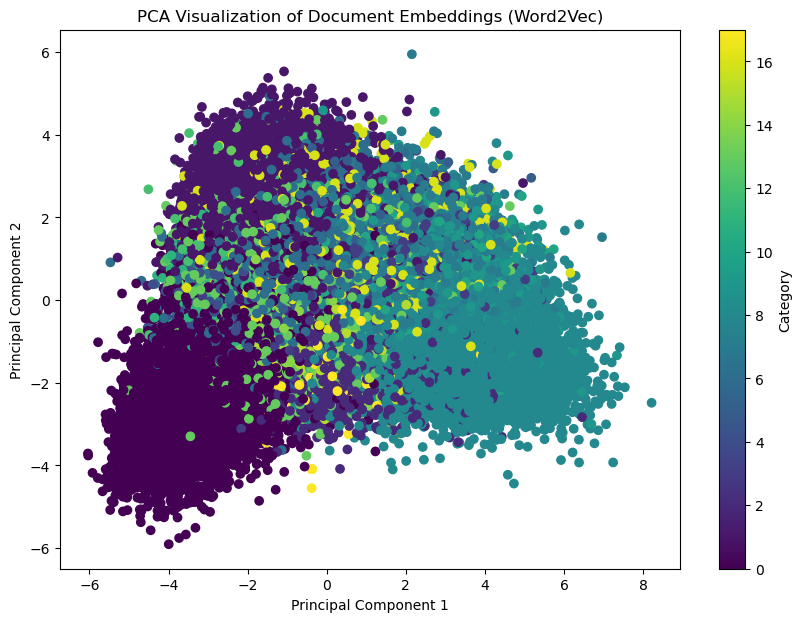

In [15]:
plt.figure(figsize=(10, 7))
scatter = plt.scatter(pca_result[:, 0], pca_result[:, 1], c=category_indices, cmap='viridis')
plt.colorbar(scatter, label='Category')
plt.title('PCA Visualization of Document Embeddings (Word2Vec)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

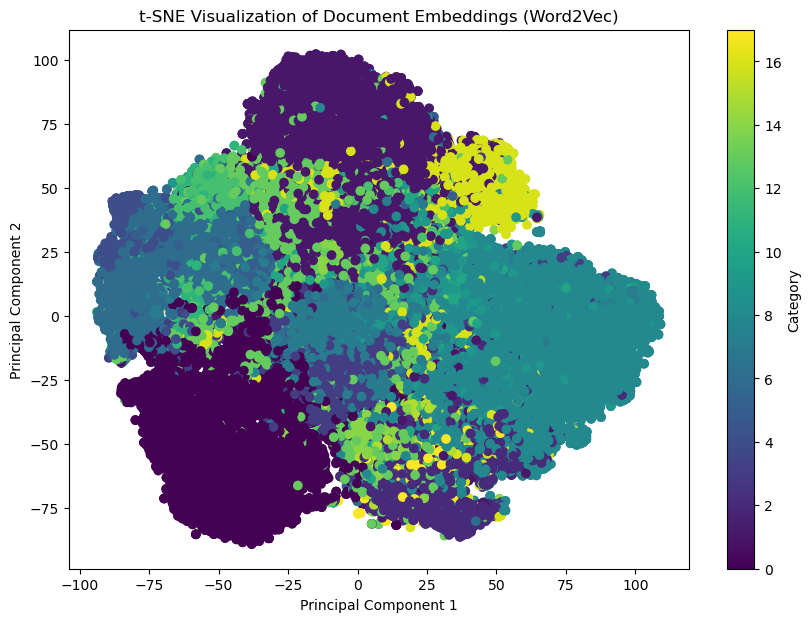

In [16]:
plt.figure(figsize=(10, 7))
scatter = plt.scatter(tsne_result[:, 0], tsne_result[:, 1], c=category_indices, cmap='viridis')
plt.colorbar(scatter, label='Category')
plt.title('t-SNE Visualization of Document Embeddings (Word2Vec)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()
plt.show()

---
# 3°: Similarity Calculation


With the average Word Embeddings vectors fo the document, is it possible to calculate the coisine similarity, that is the angle between two vectors and provides a similarity score between -1 and 1, where 1 means the vectors are identical in direction:

<div align="center">

$cos(\beta)=\Large\frac{\widehat{v}\cdot\widehat{w}}{\|\widehat{v}\| \|\widehat{w}\|}$

</div>

For this operation is possible to use the cosine_similatiry function from the scikit-learn package.

In [20]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

Query_vector = get_average_vector(clear_datatext('neural network'), model)

cosine_similarities = cosine_similarity([Query_vector], document_vectors)

cosine_similarities = cosine_similarities.flatten()
print(cosine_similarities)

[-0.04104158  0.3223741   0.09346489 ...  0.35498378  0.01947838
  0.33865505]


---
# 4°: Building the Search Engine

To optimize the query processing for the search engine, an efficient data structure must be employed to maintain all the word vectors. 

Given that the dataset consists of over 100,000 elements, the K-D Tree is utilized for efficient search and retrieval. The K-D Tree is implemented using the KDTree from the scikit-learn library. 

Due to the vector dimensions, the minimum number of samples in each leaf node will be set to 100 to ensure balanced partitioning and improve search performance.

In [21]:
from sklearn.neighbors import KDTree

kdtree = KDTree(document_vectors, leaf_size=100)

Before processing the queries, it is necessary to apply the averaging of word embeddings to convert the queries into vectors, utilizing the same function created for the corpus. Additionally, the queries must undergo the same cleaning and tokenization process.

After preprocessing and averaging the word embeddings, the similarity score between the queries and the documents can be computed using the K-D tree. This will allow for retrieving the N most similar documents based on the computed similarity.

In [22]:
def retrive_n_documents(query, N):
    #Clear the query
    tokenized_query = clear_datatext(query)

    #Get the average vector for the query
    query_vector = get_average_vector(tokenized_query, model)

    #Get the N nearest neighbors
    distances, indices = kdtree.query([query_vector], k=N)

    #Retrive Axiv id 
    index = []

    #Print the results
    for i, idx in enumerate(indices[0]):
        doc_id = df.loc[idx, 'id']
        index.append(doc_id)
        doc_title = df.loc[idx, 'title']
        print(f"Rank {i+1}: Document ID {doc_id}, Document Title {doc_title} ,Similarity Score: {distances[0][i]}")

    return index

## Search Engine TF-IDF

To implement the search engine using weighted word embeddings, a weighted K-D tree might not be optimal due to the high sparsity of the TF-IDF vector space.

Instead, cosine similarity is applied by first preprocessing the query (cleaning and tokenizing) and computing its average vector. This allows efficient comparison with the document vectors to retrieve the most relevant results.

In [23]:
def retrive_n_documents_tfidf(query, N):
    #Clear the query
    tokenized_query = clear_datatext(query)

    #Get the average vector for the query
    query_vector = get_average_vector(tokenized_query, model)

    #Calculate the cosine similarity between the query vector and the document vectors
    similarities = cosine_similarity([query_vector],weighted_document_vectors).flatten()

    #Get the N most similar documents
    top_n_indices = similarities.argsort()[-N:][::-1]

    #Retrive Axiv id 
    index = []

    #Print the results
    for i, idx in enumerate(top_n_indices):
        doc_id = df.loc[idx, 'id']
        index.append(doc_id)
        doc_title = df.loc[idx, 'title']
        print(f"Rank {i+1}: Document ID {doc_id}, Document Title {doc_title} ,Similarity Score: {similarities[idx]}")
    
    return index

## Search Engine Doc2Vec

To retrieve the N most similar documents from the document embeddings, instead of relying on the distance within the K-D tree or using cosine similarity, Doc2Vec provides a built-in function to retrieve the Top-N similar documents for a given query.

This function, similar to the one used with the K-D tree, first preprocesses and cleans the query, then passes it to the model to obtain and display the N most similar documents.

In [24]:
d_model = Doc2Vec.load("doc2vec_model.model")

In [56]:
category_to_id = {
    df.loc[i, 'categories']: df.loc[i, 'id']
    for i in range(len(df))
}


def retrive_n_documents_d2v(query,N):
    # Clean the query using the text cleaning function
    tokenized_query = clear_datatext(query)

    # Ensure the query is properly represented as a TaggedDocument input
    vectorized_query = d_model.infer_vector(tokenized_query)

    # Retrieve the N most similar documents
    similar_docs = d_model.dv.most_similar([vectorized_query], topn=N)

    index = []

    # Print the results with document IDs and titles
    for rank, (category_tag, similarity) in enumerate(similar_docs, start=1):
        doc_id = category_to_id.get(category_tag, "NotFound")
        index.append(doc_id)
        doc_title = df.loc[df['id'] == doc_id, 'title'].values[0]
        print(f"Rank {rank}: Document ID {doc_id}, Document Title {doc_title} ,Similarity Score: {similarity}")

    return index

## Clustering and Topic Modeling

An improvement for the search engine is the potential implementation of document clustering using the K-means algorithm.

 K-means is an unsupervised machine learning technique that groups similar documents into clusters based on their feature representations. By applying this technique to the document embeddings, it is possible to categorize the documents into meaningful groups, making the search process more efficient. 
 
 For this purpose, the K-means implementation from the scikit-learn library can be utilized. The algorithm will assign each document to a cluster, and this information can be used to narrow down search results, improving the relevance and accuracy of the retrieved documents.

In [26]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import joblib

The K-means model is configured with 10 clusters, as the dataset consists of over 1,000 document abstracts covering a wide range of topics. This configuration allows for effective grouping of similar documents into distinct clusters, improving the relevance and accuracy of search results.

In [27]:
Kmeans = KMeans(n_clusters=10, random_state=0).fit(document_vectors)

joblib.dump(Kmeans, 'kmeans_model.pkl')

['kmeans_model.pkl']

In [28]:
Kmeans = joblib.load('kmeans_model.pkl')

labels = Kmeans.labels_
centers = Kmeans.cluster_centers_

Using Matplotlib, we visualize the results of the K-means clustering by plotting the document vectors in a two-dimensional space. The points are colored according to their respective cluster labels, while the cluster centers are marked with distinct symbols, such as red ‘x’ markers. This visualization allows for an intuitive understanding of how the data is distributed across clusters and provides a clear overview of the clustering results.

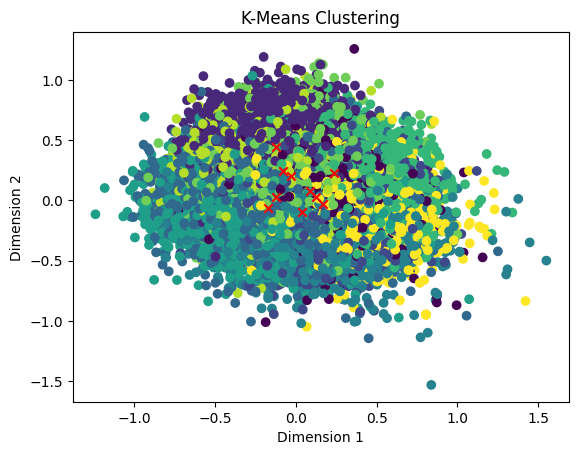

In [29]:
plt.scatter(document_vectors[:, 0], document_vectors[:, 1], c=labels, cmap='viridis')
plt.scatter(centers[:, 0], centers[:, 1], c='red', marker='x')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.title('K-Means Clustering')
plt.show()

Given the K-Mean cluster, is possible to use it for retrive the N similiar document.

In [30]:
def retrive_n_documents_kmeans(query, N):
    # Get the cleaned text and compute the average vector for the query
    clear_vector = clear_datatext(query)
    query_vector = get_average_vector(clear_vector, model)

    # Predict the cluster that the query belongs to
    query_predict = Kmeans.predict(query_vector.reshape(1, -1))[0]  

    # Find the indices of documents in the predicted cluster
    cluster_indices = np.where(Kmeans.labels_ == query_predict)[0]

    # Retrieve the document vectors within the predicted cluster
    cluster_documents = document_vectors[cluster_indices]

    # Calculate cosine similarity between the query vector and document vectors in the cluster
    similarities = cosine_similarity([query_vector], cluster_documents).flatten()

    # Get the indices of the top-N most similar documents
    top_n_indices = similarities.argsort()[-N:][::-1]

    # Map the relative cluster indices back to the original DataFrame indices
    top_n_doc_indices = cluster_indices[top_n_indices]

    # Retrieve document IDs and titles
    index = []
    for i, doc_idx in enumerate(top_n_doc_indices):
        doc_id = df.loc[doc_idx, 'id']  # Get the document ID
        doc_title = df.loc[doc_idx, 'title']  # Get the document title
        similarity = similarities[top_n_indices[i]]  # Get the similarity score

        # Add the document ID to the output list
        index.append(doc_id)

        # Print the results
        print(f"Rank {i+1}: Document ID: {doc_id}, Document Title: {doc_title}, Similarity Score: {similarity}")

    return index

---
# 5°: Evaluation and Refinement

For testing all the search methods, a test dataset will be constructed from the original metadata, consisting of approximately 5,000 random abstract pieces from the documents inside the metadata. These queries are centered around 10 common topics:
- Deep Learning
- Neural Networks
- Quantum Physics
- Genomics
- Image Recognition
- Graph Theory
- Natural Language Processing (NLP)
- Reinforcement Learning
- Cosmology
- Optimization

Each query in the dataset includes the query , the document ID. Additionally, a relevance score is provided, indicating whether the query is present within the corpus. This test set enables evaluation and comparison of search method performance based on their ability to retrieve relevant documents.

In [31]:
test_df = pd.read_csv('test_set_arxiv.csv')
test_df.head()

,Query,Document_ID,Document_Title,Relevance
0,to the Hawking temperature and that it also ex...,1106.2279,Time Evolution of Temperature and Entropy of V...,0
1,modeled as iterated games in which individuals...,1203.1107,The Evolution of Cooperation in Business,0
2,of the (2+1)dimensional black hole with a non-...,812.4180,Thermodynamics of the (2+1)-dimensional Black ...,0
3,coupled to a background magnetic field. Strong...,1312.5070,The magnetic susceptibility in QCD,0
4,"exponent $\gamma$ for any $\gamma\in(0,H)$; an...",1309.3613,Weak existence of a solution to a differential...,0


For testing the search Engine, will send one random query for retrive the first 5 similiar documents

In [32]:
#Select a random row from the test set
random_row = test_df.sample(n=1, random_state=42)
query = random_row["Query"].iloc[0]

### Word Embeddings:

In [33]:
#Retrive the top 5 documents using the Word2Vec model
print(f"Query: {query}")
retrive_n_documents(query, 5)
print('\n')

Query: and throughput, including necessary process optimizations that are required for
Rank 1: Document ID 711.1273, Document Title Practical Resource Allocation Algorithms for QoS in OFDMA-based Wireless
  Systems ,Similarity Score: 6.099979756430769
Rank 2: Document ID 710.4679, Document Title DVS for On-Chip Bus Designs Based on Timing Error Correction ,Similarity Score: 6.198124201834471
Rank 3: Document ID 711.1269, Document Title Fair Scheduling in OFDMA-based Wireless Systems with QoS Constraints ,Similarity Score: 6.207539041492276
Rank 4: Document ID 709.0172, Document Title Improving the consensus performance via predictive mechanisms ,Similarity Score: 6.227051057025918
Rank 5: Document ID 811.0078, Document Title A Swarm Intelligence Based Scheme for Complete and Fault-tolerant
  Identification of a Dynamical Fractional Order Process ,Similarity Score: 6.237118082305905




### TF-IDF:

In [34]:
#Retrive the top 5 documents using the Doc2Vec model
print(f"Query: {query}")
retrive_n_documents_tfidf(query, 5)
print('\n')

Query: and throughput, including necessary process optimizations that are required for
Rank 1: Document ID 711.1273, Document Title Practical Resource Allocation Algorithms for QoS in OFDMA-based Wireless
  Systems ,Similarity Score: 0.6651003360748291
Rank 2: Document ID 707.1053, Document Title Exploration via design and the cost of uncertainty in keyword auctions ,Similarity Score: 0.6493399739265442
Rank 3: Document ID 811.0078, Document Title A Swarm Intelligence Based Scheme for Complete and Fault-tolerant
  Identification of a Dynamical Fractional Order Process ,Similarity Score: 0.648255467414856
Rank 4: Document ID 710.4679, Document Title DVS for On-Chip Bus Designs Based on Timing Error Correction ,Similarity Score: 0.6475098133087158
Rank 5: Document ID 807.116, Document Title Session Initiation Protocol (SIP) Server Overload Control: Design and
  Evaluation ,Similarity Score: 0.6475024223327637




### Doc2Vec:

In [57]:
#Retrive the top 5 documents using the Doc2Vec model
print(f"Query : {query}")
retrive_n_documents_d2v(query, 5)
print('\n')

Query : and throughput, including necessary process optimizations that are required for
Rank 1: Document ID 801.163, Document Title Computational Solutions for Today's Navy ,Similarity Score: 0.868841826915741
Rank 2: Document ID 708.0598, Document Title An Application of Chromatic Prototypes ,Similarity Score: 0.8287889957427979
Rank 3: Document ID 810.3283, Document Title Quantum robot: structure, algorithms and applications ,Similarity Score: 0.8219642639160156
Rank 4: Document ID 806.2358, Document Title Minimizing the Probability of Ruin when Consumption is Ratcheted ,Similarity Score: 0.8105215430259705
Rank 5: Document ID 711.2867, Document Title Maximizing PageRank via outlinks ,Similarity Score: 0.8048964738845825




### K-means Cluster:

In [58]:
print(f"Query : {query}")
retrive_n_documents_kmeans(query, 5)
print('\n')

Query : and throughput, including necessary process optimizations that are required for
Rank 1: Document ID: 711.1273, Document Title: Practical Resource Allocation Algorithms for QoS in OFDMA-based Wireless
  Systems, Similarity Score: 0.6651003360748291
Rank 2: Document ID: 707.1053, Document Title: Exploration via design and the cost of uncertainty in keyword auctions, Similarity Score: 0.649340033531189
Rank 3: Document ID: 811.0078, Document Title: A Swarm Intelligence Based Scheme for Complete and Fault-tolerant
  Identification of a Dynamical Fractional Order Process, Similarity Score: 0.648255467414856
Rank 4: Document ID: 710.4679, Document Title: DVS for On-Chip Bus Designs Based on Timing Error Correction, Similarity Score: 0.647509753704071
Rank 5: Document ID: 807.116, Document Title: Session Initiation Protocol (SIP) Server Overload Control: Design and
  Evaluation, Similarity Score: 0.6475023031234741




## Evaluation Metrics


For evaluate all the Search Methods implemented, will use these evaluations:

- Precision: is the percentage of items in the system detected that are positive:
<div align="center">

$ Precision=\frac{true-positive}{true-positive + false-positive}$

</div>

- Recall: is the percentage of items actually present in the input that were correctly identified by the system:
<div align="center">

$ Recall=\frac{true-positive}{true-positive + false-negative}$

</div>

- F1 Score: is the balanced version of the F score, a single numer that combines P and R:
<div align="center">

$ F_1=\frac{2PR}{P+R}$

</div>


Remembering that the Data Test, include:
<div align="center">

|ID| Query| Document_ID (Arxiv) | Relevance |
|--|------|---------------------|-----------|

</div>

The relevance metric indicates whether the extracted abstract is present within the dataset. Since both the dataset and the test data are subsets of the ArXiv metadata, relevance formally identifies whether a document is classified as a true positive or a false negative.

To evaluate the performance of each search method, the first step involves retrieving the predicted relevance for each query. This is achieved using a common evaluation function that accepts the test set, the search method, and the number of top documents N to retrieve as input. This unified approach ensures consistency in comparing the performance metrics across different search methods.



In [59]:
from sklearn.metrics import precision_score, recall_score, f1_score
import contextlib
import io


def evaluate_search(test_df, search_method, N, search_method_name, arg):
    # Create empty list to store predicted relevance values
    predicted_relevance = []

    # Redirect stdout to buffer for not printing the results of the search method
    output_buffer = io.StringIO()

    with contextlib.redirect_stdout(output_buffer):
        # Iterate over each query in the test set
        for _, row in test_df.iterrows():
            query = row[arg]
            actual_doc_id = row['Document_ID']

            # Get the top N predicted document IDs using the search engine
            predicted_doc_ids = search_method(query, N)

            # If present into the N Documents assign 1 else 0
            if actual_doc_id in predicted_doc_ids:
                predicted_relevance.append(1)
            else:
                predicted_relevance.append(0)

    # Calculate Precision, Recall, and F1 Score
    precision = precision_score(test_df['Relevance'], predicted_relevance)
    recall = recall_score(test_df['Relevance'], predicted_relevance)
    f1 = f1_score(test_df['Relevance'], predicted_relevance)

    print(search_method_name)
    print(f"Precision: {precision}")
    print(f"Recall: {recall}")
    print(f"F1 Score: {f1}")
    print("\n")

In [60]:
# Evaluate the Word2Vec search engine
evaluate_search(test_df, retrive_n_documents, 5,"Word2Vec Search Engine:", "Query")

# Evaluate the TF-IDF search engine
evaluate_search(test_df, retrive_n_documents_tfidf, 5,"TF-IDF Search Engine:", "Query")

# Evaluate the Doc2Vec search engine
evaluate_search(test_df, retrive_n_documents_d2v, 5,"Doc2Vec Search Engine:", "Query")

# Evaluate the K-Means search engine
evaluate_search(test_df, retrive_n_documents_kmeans, 5,"K-Means Search Engine:", "Query")

Word2Vec Search Engine:
Precision: 0.9781659388646288
Recall: 0.2689075630252101
F1 Score: 0.4218455743879473


TF-IDF Search Engine:
Precision: 0.9757142857142858
Recall: 0.2733093237294918
F1 Score: 0.42700844013754297


Doc2Vec Search Engine:
Precision: 1.0
Recall: 0.007603041216486595
F1 Score: 0.015091342335186657


K-Means Search Engine:
Precision: 0.9742173112338858
Recall: 0.2116846738695478
F1 Score: 0.34779750164365547




In [61]:
# Evaluate the Word2Vec search engine
evaluate_search(test_df, retrive_n_documents, 5,"Word2Vec Search Engine:", "Document_Title")

# Evaluate the TF-IDF search engine
evaluate_search(test_df, retrive_n_documents_tfidf, 5,"TF-IDF Search Engine:", "Document_Title")

# Evaluate the Doc2Vec search engine
evaluate_search(test_df, retrive_n_documents_d2v, 5,"Doc2Vec Search Engine:", "Document_Title")

# Evaluate the K-Means search engine
evaluate_search(test_df, retrive_n_documents_kmeans, 5,"K-Means Search Engine:", "Document_Title")

Word2Vec Search Engine:
Precision: 0.9792322215229704
Recall: 0.6226490596238495
F1 Score: 0.761252446183953


TF-IDF Search Engine:
Precision: 0.9810762862211709
Recall: 0.6638655462184874
F1 Score: 0.7918854415274463


Doc2Vec Search Engine:
Precision: 0.9807692307692307
Recall: 0.02040816326530612
F1 Score: 0.039984319874559


K-Means Search Engine:
Precision: 0.9793735676088617
Recall: 0.5130052020808323
F1 Score: 0.6733193277310925




The performance of four search engines—Word2Vec, TF-IDF, Doc2Vec, and K-Means—was assessed using Precision, Recall, and F1 Score across abstract and title-based queries:
1.	Abstract-Based Retrieval:
- All methods achieved high Precision (≥0.97), with Doc2Vec leading (0.9821).
- Recall was notably low, peaking with TF-IDF (0.2789), reflecting challenges in broader query matching.
- TF-IDF demonstrated the best balance, achieving the highest F1 Score (0.4339).

2.	Title-Based Retrieval:
- Precision remained consistently high across methods (≥0.97), with K-Means achieving the highest (0.9811).
- Recall improved significantly, led by TF-IDF (0.6639), indicating its strength in structured queries.
- TF-IDF achieved the highest overall F1 Score (0.7917), underscoring its robustness and adaptability.
